In [5]:
import os
import pandas as pd

repo = r'C:\Users\ohimo\VESP-'

for pid in ['sub-R1001P', 'sub-R1002P', 'sub-R1003P']:
    path = os.path.join(repo, f'{pid}_electrode_mapping.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"{pid}: {len(df)} electrodes, columns: {list(df.columns)}")
    else:
        print(f"MISSING: {path}")

sub-R1001P: 88 electrodes, columns: ['Electrode', 'X', 'Y', 'Z', 'Brain_Region']
sub-R1002P: 74 electrodes, columns: ['Electrode', 'X', 'Y', 'Z', 'Brain_Region']
sub-R1003P: 100 electrodes, columns: ['Electrode', 'X', 'Y', 'Z', 'Brain_Region']


In [6]:
import os
import numpy as np
import pandas as pd

repo = r'C:\Users\ohimo\VESP-'

# ── CLINICAL EZ REGIONS ──────────────────────────────────────────────────────
# Based on temporal lobe epilepsy literature (Jobst & Cascino 2015, JAMA)
# These are the known seizure-onset regions for drug-resistant TLE
EZ_REGIONS  = ['parahippocampal', 'temporalpole', 'entorhinal', 'hippocampus']
PZ_REGIONS  = ['fusiform', 'inferiortemporal', 'middletemporal', 'superiortemporal']

def load_patient(pid):
    df = pd.read_csv(os.path.join(repo, f'{pid}_electrode_mapping.csv'))
    coords  = df[['X','Y','Z']].values.astype(float)
    names   = df['Electrode'].values
    regions = df['Brain_Region'].values
    return coords, names, regions

def classify_electrodes(regions):
    ez, pz, hz = [], [], []
    for i, r in enumerate(regions):
        r = str(r).lower()
        if any(e in r for e in EZ_REGIONS):
            ez.append(i)
        elif any(p in r for p in PZ_REGIONS):
            pz.append(i)
        else:
            hz.append(i)
    return np.array(ez), np.array(pz), np.array(hz)

def build_connectivity(coords, regions):
    """
    Anatomical connectivity from real MNI coordinates.
    Exponential decay W_ij = exp(-d_ij / 35mm)
    lambda=35mm: standard short-range cortical estimate
    (Sporns 2011, Networks of the Brain)
    Same-region electrodes get 1.5x boost (shared local field)
    """
    n = len(coords)
    W = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = np.linalg.norm(coords[i] - coords[j])
            w = np.exp(-d / 35.0)
            if regions[i] == regions[j] and regions[i] != 'unknown':
                w *= 1.5
            W[i,j] = w
            W[j,i] = w
    row_max = W.max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1
    W = W / row_max
    np.fill_diagonal(W, 0)
    return W

# Load and classify all 3 patients
patients = ['sub-R1001P', 'sub-R1002P', 'sub-R1003P']
data = {}

for pid in patients:
    coords, names, regions = load_patient(pid)
    ez_idx, pz_idx, hz_idx = classify_electrodes(regions)
    W = build_connectivity(coords, regions)
    data[pid] = dict(coords=coords, names=names, regions=regions,
                     ez_idx=ez_idx, pz_idx=pz_idx, hz_idx=hz_idx, W=W)
    print(f"{pid}: {len(names)} electrodes | "
          f"EZ={len(ez_idx)} {[names[i] for i in ez_idx]} | "
          f"PZ={len(pz_idx)} | HZ={len(hz_idx)}")

print("\nConnectivity built from real MNI coordinates. Ready to simulate.")

sub-R1001P: 88 electrodes | EZ=2 ['LAT1', 'LDH3'] | PZ=26 | HZ=60
sub-R1002P: 74 electrodes | EZ=7 ['LAT1', 'LAT2', 'LAT3', 'LMT1', 'LMT2', 'LMT3', 'RAT1'] | PZ=17 | HZ=50
sub-R1003P: 100 electrodes | EZ=2 ['LG33', 'LG41'] | PZ=26 | HZ=72

Connectivity built from real MNI coordinates. Ready to simulate.


In [7]:
def gl_weights(beta, n):
    """Grunwald-Letnikov weights for fractional derivative of order beta"""
    w = np.zeros(n)
    w[0] = 1.0
    for j in range(1, n):
        w[j] = w[j-1] * (1.0 - (1.0 + beta) / j)
    return w

def simulate(pid, beta=0.8, duration=3000, dt=1, seed=42):
    """
    Fractional-order seizure simulation on real patient electrode network.
    
    Physics:
    - Epileptor-inspired bistable dynamics per electrode
    - Network coupling via anatomical connectivity W
    - Fractional memory via Grunwald-Letnikov method
    - EZ electrodes initialized near threshold (clinical prior)
    """
    np.random.seed(seed)
    d = data[pid]
    coords  = d['coords']
    regions = d['regions']
    ez_idx  = d['ez_idx']
    W       = d['W']
    n       = len(regions)

    n_steps = int(duration / dt)
    MEM     = 120
    gl_w    = gl_weights(beta, MEM)

    # Initial state: all electrodes at rest (-2.0)
    # EZ electrodes near threshold (-1.65) — clinical: irritative zone
    traj = np.full((n_steps, n), -2.0)
    if len(ez_idx) > 0:
        traj[:MEM, ez_idx] = -1.65 + np.random.normal(0, 0.02,
                                                        (MEM, len(ez_idx)))

    for t in range(MEM, n_steps):
        xc = traj[t-1]
        xh = traj[max(0, t-MEM):t][::-1]

        # Anatomical network coupling
        coupling = W @ (xc - xc.mean()) * 0.05

        # Bistable dynamics f(x)
        f_x = 0.015 * (xc + 2.0) * (1.8 - xc) + coupling
        f_x[xc > -1.2] += 0.12   # threshold crossing

        # Grunwald-Letnikov fractional correction
        n_hist   = min(len(xh), MEM)
        frac_corr = (gl_w[:n_hist] @ xh[:n_hist]) / (dt ** beta)
        x_new    = xc + dt**beta * f_x - dt**beta * frac_corr * 0.001
        traj[t]  = np.clip(x_new, -3.0, 2.5)

    times = np.arange(n_steps) * dt
    return traj, times

# Run all 3 patients at beta=0.8
print("Running simulations...\n")
sims = {}
for pid in patients:
    traj, times = simulate(pid, beta=0.8)
    sims[pid] = dict(traj=traj, times=times)
    ez_idx = data[pid]['ez_idx']
    if len(ez_idx) > 0:
        peak = np.max(traj[:, ez_idx])
        active_pct = np.mean(traj[:, ez_idx] > -1.5) * 100
    else:
        peak, active_pct = 0, 0
    print(f"{pid}: peak activity={peak:.3f} | "
          f"EZ active {active_pct:.1f}% of simulation")

print("\nSimulations complete.")

Running simulations...

sub-R1001P: peak activity=2.500 | EZ active 95.9% of simulation
sub-R1002P: peak activity=2.500 | EZ active 82.2% of simulation
sub-R1003P: peak activity=nan | EZ active 0.0% of simulation

Simulations complete.


In [10]:
def simulate_stable(pid, beta=0.8, duration=3000, dt=1, seed=42):
    np.random.seed(seed)
    d = data[pid]
    regions = d['regions']
    ez_idx  = d['ez_idx']
    W       = d['W']
    n       = len(regions)

    n_steps = int(duration / dt)
    MEM     = 80

    # Normalized GL weights
    raw_w = np.zeros(MEM)
    raw_w[0] = 1.0
    for j in range(1, MEM):
        raw_w[j] = raw_w[j-1] * (1.0 - (1.0 + beta) / j)
    gl_w = raw_w / (np.abs(raw_w).sum() + 1e-12)

    traj = np.full((n_steps, n), -2.0)

    # EZ starts ABOVE threshold so it fires immediately
    if len(ez_idx) > 0:
        traj[:MEM, ez_idx] = -1.4 + np.random.normal(0, 0.01, (MEM, len(ez_idx)))

    for t in range(1, n_steps):
        xc = traj[t-1].copy()

        # Coupling from real anatomy
        coupling = W @ (xc - xc.mean()) * 0.03

        # Bistable per-electrode dynamics
        # x = -2.0: stable rest
        # x = -1.6: unstable threshold  
        # x = 0.5:  stable seizure state
        f_x = (xc - (-2.0)) * (xc - (-1.6)) * (0.5 - xc) * (-1.0)
        f_x = f_x * 0.02 + coupling

        # GL fractional memory
        start = max(0, t - MEM)
        hist  = traj[start:t][::-1]
        n_h   = len(hist)
        frac  = gl_w[:n_h] @ hist

        x_new = xc + dt * f_x - 0.0003 * (frac - xc)
        x_new = np.clip(x_new, -2.5, 1.0)

        bad = ~np.isfinite(x_new)
        if bad.any():
            x_new[bad] = xc[bad]

        traj[t] = x_new

    times = np.arange(n_steps) * dt
    return traj, times

# Test
print("Running...\n")
sims = {}
for pid in patients:
    traj, times = simulate_stable(pid, beta=0.8)
    sims[pid] = dict(traj=traj, times=times)
    ez_idx = data[pid]['ez_idx']
    if len(ez_idx) > 0:
        ez_mean    = traj[:, ez_idx].mean(axis=1)
        peak       = ez_mean.max()
        rest_mean  = traj[:, data[pid]['hz_idx']].mean()
        has_nan    = np.isnan(traj).any()
        print(f"{pid}: EZ peak={peak:.3f} | healthy mean={rest_mean:.3f} | NaN={has_nan}")
    else:
        print(f"{pid}: no EZ found")

print("\nDone.")

Running...

sub-R1001P: EZ peak=1.000 | healthy mean=-0.762 | NaN=False
sub-R1002P: EZ peak=0.500 | healthy mean=-1.106 | NaN=False
sub-R1003P: EZ peak=-1.398 | healthy mean=-2.000 | NaN=False

Done.


In [11]:
# Diagnose R1003P
pid = 'sub-R1003P'
d = data[pid]
ez_idx = d['ez_idx']
pz_idx = d['pz_idx']
names  = d['names']
regions = d['regions']

print("R1003P EZ electrodes:")
for i in ez_idx:
    print(f"  {names[i]} -> {regions[i]}")

print("\nR1003P PZ electrodes (first 10):")
for i in pz_idx[:10]:
    print(f"  {names[i]} -> {regions[i]}")

print("\nAll unique regions:")
for r in sorted(set(regions)):
    count = sum(1 for x in regions if x == r)
    print(f"  {r}: {count} electrodes")

R1003P EZ electrodes:
  LG33 -> temporalpole
  LG41 -> temporalpole

R1003P PZ electrodes (first 10):
  LG34 -> superiortemporal
  LG42 -> middletemporal
  LG43 -> superiortemporal
  LG44 -> superiortemporal
  LG45 -> superiortemporal
  LG49 -> middletemporal
  LG50 -> middletemporal
  LG51 -> superiortemporal
  LG52 -> superiortemporal
  LG57 -> inferiortemporal

All unique regions:
  caudalmiddlefrontal: 7 electrodes
  fusiform: 2 electrodes
  inferiortemporal: 8 electrodes
  lateraloccipital: 1 electrodes
  lateralorbitofrontal: 4 electrodes
  middletemporal: 6 electrodes
  parsopercularis: 3 electrodes
  parsorbitalis: 3 electrodes
  parstriangularis: 3 electrodes
  postcentral: 6 electrodes
  precentral: 6 electrodes
  rostralmiddlefrontal: 18 electrodes
  superiorfrontal: 6 electrodes
  superiortemporal: 10 electrodes
  supramarginal: 8 electrodes
  temporalpole: 2 electrodes
  unknown: 7 electrodes


In [13]:
def simulate_final(pid, beta=0.8, duration=3000, dt=1, seed=42):
    np.random.seed(seed)
    d       = data[pid]
    regions = d['regions']
    ez_idx  = d['ez_idx']
    pz_idx  = d['pz_idx']
    W       = d['W']
    n       = len(regions)

    n_steps = int(duration / dt)
    MEM     = 80

    raw_w = np.zeros(MEM)
    raw_w[0] = 1.0
    for j in range(1, MEM):
        raw_w[j] = raw_w[j-1] * (1.0 - (1.0 + beta) / j)
    gl_w = raw_w / (np.abs(raw_w).sum() + 1e-12)

    x0 = np.full(n, -2.2)
    if len(ez_idx) > 0:
        x0[ez_idx] = -1.4   # stronger epileptogenicity
    if len(pz_idx) > 0:
        x0[pz_idx] = -1.85

    traj = np.full((n_steps, n), -2.0)

    # EZ: initialize well into seizure state
    if len(ez_idx) > 0:
        traj[:MEM, ez_idx] = 0.5 + np.random.normal(0, 0.02,
                                                      (MEM, len(ez_idx)))

    for t in range(1, n_steps):
        xc = traj[t-1].copy()

        coupling = W @ (xc - xc.mean()) * 0.04

        f_x = (xc - x0) * (xc - (x0 + 0.4)) * (0.8 - xc) * (-1.0)
        f_x = f_x * 0.025 + coupling

        start = max(0, t - MEM)
        hist  = traj[start:t][::-1]
        n_h   = len(hist)
        frac  = gl_w[:n_h] @ hist

        x_new = xc + dt * f_x - 0.0003 * (frac - xc)
        x_new = np.clip(x_new, -2.8, 1.0)

        bad = ~np.isfinite(x_new)
        if bad.any():
            x_new[bad] = xc[bad]

        traj[t] = x_new

    times = np.arange(n_steps) * dt
    return traj, times

# Run and check
print("Running...\n")
sims = {}
for pid in patients:
    traj, times = simulate_final(pid, beta=0.8)
    sims[pid]   = dict(traj=traj, times=times)
    ez_idx = data[pid]['ez_idx']
    pz_idx = data[pid]['pz_idx']
    hz_idx = data[pid]['hz_idx']
    ez_peak = traj[:, ez_idx].max()     if len(ez_idx) > 0 else float('nan')
    pz_peak = traj[:, pz_idx].max()     if len(pz_idx) > 0 else float('nan')
    hz_mean = traj[:, hz_idx].mean()    if len(hz_idx) > 0 else float('nan')
    # Propagation: did seizure spread AFTER t=500ms?
    late     = traj[500:, :]
    pz_late  = late[:, pz_idx].max()   if len(pz_idx) > 0 else float('nan')
    print(f"{pid}: EZ={ez_peak:.3f} | PZ={pz_peak:.3f} | "
          f"PZ late={pz_late:.3f} | HZ={hz_mean:.3f}")

print("\nDone.")

Running...

sub-R1001P: EZ=1.000 | PZ=1.000 | PZ late=1.000 | HZ=-0.907
sub-R1002P: EZ=1.000 | PZ=1.000 | PZ late=1.000 | HZ=-1.283
sub-R1003P: EZ=0.510 | PZ=-2.000 | PZ late=-2.000 | HZ=-2.000

Done.


In [14]:
# Run all 3 patients x 3 beta values
print("Running all beta comparisons...\n")

beta_values = [1.0, 0.8, 0.6]
all_sims = {}   # all_sims[pid][beta] = dict(traj, times)

for pid in patients:
    all_sims[pid] = {}
    for beta in beta_values:
        traj, times = simulate_final(pid, beta=beta)
        all_sims[pid][beta] = dict(traj=traj, times=times)
    
    # Quick sanity check
    ez_idx = data[pid]['ez_idx']
    for beta in beta_values:
        traj = all_sims[pid][beta]['traj']
        ez_peak = traj[:, ez_idx].max() if len(ez_idx) > 0 else float('nan')
        print(f"  {pid} beta={beta}: EZ peak={ez_peak:.3f}")
    print()

print("All simulations complete. Ready to plot.")

Running all beta comparisons...

  sub-R1001P beta=1.0: EZ peak=1.000
  sub-R1001P beta=0.8: EZ peak=1.000
  sub-R1001P beta=0.6: EZ peak=1.000

  sub-R1002P beta=1.0: EZ peak=1.000
  sub-R1002P beta=0.8: EZ peak=1.000
  sub-R1002P beta=0.6: EZ peak=1.000

  sub-R1003P beta=1.0: EZ peak=0.510
  sub-R1003P beta=0.8: EZ peak=0.510
  sub-R1003P beta=0.6: EZ peak=0.510

All simulations complete. Ready to plot.


In [16]:
def simulate_final(pid, beta=0.8, duration=4000, dt=1, seed=42):
    """
    Full Epileptor-inspired simulation with seizure onset AND termination.
    Uses slow permittivity variable z to terminate seizures naturally.
    """
    np.random.seed(seed)
    d       = data[pid]
    regions = d['regions']
    ez_idx  = d['ez_idx']
    pz_idx  = d['pz_idx']
    W       = d['W']
    n       = len(regions)
    n_steps = int(duration / dt)
    MEM     = 80

    # Normalized GL weights
    raw_w = np.zeros(MEM)
    raw_w[0] = 1.0
    for j in range(1, MEM):
        raw_w[j] = raw_w[j-1] * (1.0 - (1.0 + beta) / j)
    gl_w = raw_w / (np.abs(raw_w).sum() + 1e-12)

    # x0: epileptogenicity per electrode (Epileptor parameter)
    x0 = np.full(n, -2.2)   # healthy: stable rest
    if len(ez_idx) > 0:
        x0[ez_idx] = -1.6   # EZ: above bifurcation
    if len(pz_idx) > 0:
        x0[pz_idx] = -1.95  # PZ: near threshold

    # Two state variables: x (fast) and z (slow permittivity)
    # z is what terminates the seizure
    x = np.full(n, -2.0)
    z = np.full(n,  3.0)   # slow variable starts high (rest)

    if len(ez_idx) > 0:
        x[ez_idx] = -1.0    # EZ starts near threshold
        z[ez_idx] =  2.5

    traj_x = np.zeros((n_steps, n))
    traj_z = np.zeros((n_steps, n))
    traj_x[0] = x
    traj_z[0] = z

    # Store x history for GL
    x_hist = np.tile(x, (MEM, 1))  # shape (MEM, n)

    r = 0.00015   # slow variable time constant (controls seizure duration)

    for t in range(1, n_steps):
        xc = traj_x[t-1].copy()
        zc = traj_z[t-1].copy()

        # Anatomical coupling on fast variable
        coupling = W @ (xc - xc.mean()) * 0.03

        # Fast variable dynamics (simplified Epileptor pop 1)
        # dx/dt = y - f(x) - z + coupling
        # f(x) = x^3 - 3x^2  (cubic nonlinearity)
        f_x  = xc**3 - 3 * xc**2
        dx   = -f_x - zc + 3.5 + coupling

        # Slow permittivity (z terminates seizure)
        # dz/dt = r * (4*(x - x0) - z)
        dz = r * (4.0 * (xc - x0) - zc)

        # GL fractional correction on fast variable only
        gl_correction = gl_w @ x_hist   # weighted past states
        frac_term = 0.0002 * (gl_correction - xc)

        x_new = xc + dt * dx - frac_term
        z_new = zc + dt * dz

        x_new = np.clip(x_new, -3.0, 1.5)
        z_new = np.clip(z_new,  0.0, 6.0)

        # Safety
        x_new = np.where(np.isfinite(x_new), x_new, xc)
        z_new = np.where(np.isfinite(z_new), z_new, zc)

        traj_x[t] = x_new
        traj_z[t] = z_new

        # Roll history
        x_hist = np.roll(x_hist, 1, axis=0)
        x_hist[0] = x_new

    times = np.arange(n_steps) * dt
    return traj_x, traj_z, times

# Test
print("Running Epileptor simulations...\n")
all_sims = {}

for pid in patients:
    all_sims[pid] = {}
    for beta in [1.0, 0.8, 0.6]:
        tx, tz, times = simulate_final(pid, beta=beta)
        all_sims[pid][beta] = dict(traj=tx, traj_z=tz, times=times)

    ez_idx = data[pid]['ez_idx']
    for beta in [1.0, 0.8, 0.6]:
        tx = all_sims[pid][beta]['traj']
        ez_min = tx[:, ez_idx].min() if len(ez_idx) > 0 else 0
        ez_max = tx[:, ez_idx].max() if len(ez_idx) > 0 else 0
        print(f"  {pid} β={beta}: EZ range [{ez_min:.2f}, {ez_max:.2f}]")
    print()

print("Done.")

Running Epileptor simulations...

  sub-R1001P β=1.0: EZ range [-1.00, 1.50]
  sub-R1001P β=0.8: EZ range [-1.00, 1.50]
  sub-R1001P β=0.6: EZ range [-1.00, 1.50]

  sub-R1002P β=1.0: EZ range [-1.00, 1.50]
  sub-R1002P β=0.8: EZ range [-1.00, 1.50]
  sub-R1002P β=0.6: EZ range [-1.00, 1.50]

  sub-R1003P β=1.0: EZ range [-1.00, -1.00]
  sub-R1003P β=0.8: EZ range [-1.00, -1.00]
  sub-R1003P β=0.6: EZ range [-1.00, -1.00]

Done.


In [18]:
# Diagnose: trace one electrode for 50 steps manually
pid    = 'sub-R1002P'
ez_idx = data[pid]['ez_idx']
i0     = ez_idx[0]   # first EZ electrode

x  = -1.0   # starting value
z  =  2.5
x0 = -1.6

print("Step  |   x      |   z      |   f(x)   |   dx/dt  |   dz/dt")
print("-"*70)
for t in range(20):
    f_x  = x**3 - 3*x**2
    dx   = -f_x - z + 3.5
    dz   = 0.00015 * (4.0*(x - x0) - z)
    print(f"t={t:3d}  | x={x:7.4f} | z={z:7.4f} | f={f_x:7.4f} | dx={dx:7.4f} | dz={dz:7.4f}")
    x = np.clip(x + dx, -3.0, 1.5)
    z = np.clip(z + dz,  0.0, 6.0)

Step  |   x      |   z      |   f(x)   |   dx/dt  |   dz/dt
----------------------------------------------------------------------
t=  0  | x=-1.0000 | z= 2.5000 | f=-4.0000 | dx= 5.0000 | dz=-0.0000
t=  1  | x= 1.5000 | z= 2.5000 | f=-3.3750 | dx= 4.3750 | dz= 0.0015
t=  2  | x= 1.5000 | z= 2.5015 | f=-3.3750 | dx= 4.3735 | dz= 0.0015
t=  3  | x= 1.5000 | z= 2.5030 | f=-3.3750 | dx= 4.3720 | dz= 0.0015
t=  4  | x= 1.5000 | z= 2.5044 | f=-3.3750 | dx= 4.3706 | dz= 0.0015
t=  5  | x= 1.5000 | z= 2.5059 | f=-3.3750 | dx= 4.3691 | dz= 0.0015
t=  6  | x= 1.5000 | z= 2.5074 | f=-3.3750 | dx= 4.3676 | dz= 0.0015
t=  7  | x= 1.5000 | z= 2.5089 | f=-3.3750 | dx= 4.3661 | dz= 0.0015
t=  8  | x= 1.5000 | z= 2.5104 | f=-3.3750 | dx= 4.3646 | dz= 0.0015
t=  9  | x= 1.5000 | z= 2.5119 | f=-3.3750 | dx= 4.3631 | dz= 0.0015
t= 10  | x= 1.5000 | z= 2.5133 | f=-3.3750 | dx= 4.3617 | dz= 0.0015
t= 11  | x= 1.5000 | z= 2.5148 | f=-3.3750 | dx= 4.3602 | dz= 0.0015
t= 12  | x= 1.5000 | z= 2.5163 | f=-3.375

In [19]:
pid    = 'sub-R1002P'
ez_idx = data[pid]['ez_idx']
tx     = all_sims[pid][0.8]['traj']
times  = all_sims[pid][0.8]['times']

# Print actual values at key timepoints
print("EZ electrode 0 activity over time:")
for t in [0, 1, 2, 5, 10, 50, 100, 500, 1000, 2000, 3000]:
    if t < len(times):
        print(f"  t={t:5d}ms: x={tx[t, ez_idx[0]]:.4f}  "
              f"  z={all_sims[pid][0.8]['traj_z'][t, ez_idx[0]]:.4f}")

print(f"\nFull trajectory stats:")
print(f"  min={tx[:, ez_idx].min():.4f}")
print(f"  max={tx[:, ez_idx].max():.4f}")
print(f"  unique values count: {len(np.unique(tx[:, ez_idx].round(3)))}")
print(f"  value at t=100: {tx[100, ez_idx[0]]:.6f}")
print(f"  value at t=101: {tx[101, ez_idx[0]]:.6f}")

EZ electrode 0 activity over time:
  t=    0ms: x=-1.0000    z=2.5000
  t=    1ms: x=1.5000    z=2.5000
  t=    2ms: x=1.5000    z=2.5015
  t=    5ms: x=1.5000    z=2.5059
  t=   10ms: x=1.5000    z=2.5133
  t=   50ms: x=1.5000    z=2.5725
  t=  100ms: x=1.5000    z=2.6459
  t=  500ms: x=1.5000    z=3.2140
  t= 1000ms: x=1.5000    z=3.8778
  t= 2000ms: x=1.5000    z=5.0650
  t= 3000ms: x=1.5000    z=6.0000

Full trajectory stats:
  min=-1.0000
  max=1.5000
  unique values count: 2
  value at t=100: 1.500000
  value at t=101: 1.500000


In [20]:
def simulate_final(pid, beta=0.8, duration=4000, dt=0.1, seed=42):
    """
    Corrected Epileptor with proper timescales.
    dt=0.1ms for numerical accuracy.
    r=0.00035 (standard Jirsa 2014 value) for realistic seizure duration.
    """
    np.random.seed(seed)
    d       = data[pid]
    regions = d['regions']
    ez_idx  = d['ez_idx']
    pz_idx  = d['pz_idx']
    W       = d['W']
    n       = len(regions)
    n_steps = int(duration / dt)
    MEM     = 200  # longer memory in steps (but dt=0.1 so 200 = 20ms)

    # GL weights
    raw_w = np.zeros(MEM)
    raw_w[0] = 1.0
    for j in range(1, MEM):
        raw_w[j] = raw_w[j-1] * (1.0 - (1.0 + beta) / j)
    gl_w = raw_w / (np.abs(raw_w).sum() + 1e-12)

    # x0 per electrode
    x0 = np.full(n, -2.2)
    if len(ez_idx) > 0:
        x0[ez_idx] = -1.6
    if len(pz_idx) > 0:
        x0[pz_idx] = -1.95

    # Initialize
    x = np.full(n, -1.6)   # all start near rest
    z = np.full(n,  3.0)
    if len(ez_idx) > 0:
        x[ez_idx] = -1.4    # EZ: just above threshold
        z[ez_idx] =  2.8

    # Downsample storage: save every 10 steps = every 1ms
    save_every  = 10
    n_saved     = n_steps // save_every
    traj_x      = np.zeros((n_saved, n), dtype=np.float32)
    traj_z      = np.zeros((n_saved, n), dtype=np.float32)

    x_hist = np.tile(x, (MEM, 1))
    r      = 0.00035   # Jirsa 2014 standard value
    save_i = 0

    for t in range(n_steps):
        # Coupling
        coupling = W @ (x - x.mean()) * 0.02

        # Epileptor f1(x) - correct form from Jirsa 2014
        # f1 = x^3 - 3x^2  when x < 0
        # f1 = x^3 - 3x^2 + (6x-8) bump when x >= 0  (simplified here)
        f1 = np.where(x < 0,
                      x**3 - 3*x**2,
                      x**3 - 3*x**2)

        # dx = -f1 - z + 3.1 + Iext + coupling
        dx = -f1 - z + 3.1 + coupling

        # dz = r*(4*(x-x0) - z)
        dz = r * (4.0*(x - x0) - z)

        # GL fractional correction
        frac      = gl_w @ x_hist
        frac_term = 0.0001 * (frac - x)

        x_new = x + dt * dx - frac_term
        z_new = z + dt * dz

        x_new = np.clip(x_new, -2.5, 1.5)
        z_new = np.clip(z_new,  1.5, 6.5)

        x_new = np.where(np.isfinite(x_new), x_new, x)
        z_new = np.where(np.isfinite(z_new), z_new, z)

        x = x_new
        z = z_new

        x_hist = np.roll(x_hist, 1, axis=0)
        x_hist[0] = x

        if t % save_every == 0 and save_i < n_saved:
            traj_x[save_i] = x
            traj_z[save_i] = z
            save_i += 1

    times = np.arange(n_saved) * dt * save_every
    return traj_x, traj_z, times

# Quick test on R1002P only first
print("Testing R1002P...")
pid    = 'sub-R1002P'
ez_idx = data[pid]['ez_idx']

tx, tz, times = simulate_final(pid, beta=0.8)

print(f"Trajectory shape: {tx.shape}")
print(f"Time range: 0 to {times[-1]:.0f}ms")
print(f"\nEZ electrode 0 at key times:")
for t_ms in [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000]:
    idx = min(int(t_ms), len(times)-1)
    print(f"  t={t_ms:5d}ms: x={tx[idx, ez_idx[0]]:.4f}  z={tz[idx, ez_idx[0]]:.4f}")

print(f"\nUnique x values: {len(np.unique(tx[:, ez_idx[0]].round(2)))}")
print(f"x min={tx[:, ez_idx].min():.3f}  max={tx[:, ez_idx].max():.3f}")

Testing R1002P...
Trajectory shape: (4000, 74)
Time range: 0 to 3999ms

EZ electrode 0 at key times:
  t=    0ms: x=-0.5071  z=2.7999
  t=  100ms: x=1.5000  z=3.1253
  t=  500ms: x=1.5000  z=4.3370
  t= 1000ms: x=1.5000  z=5.6315
  t= 1500ms: x=1.5000  z=6.5000
  t= 2000ms: x=1.5000  z=6.5000
  t= 2500ms: x=1.5000  z=6.5000
  t= 3000ms: x=1.5000  z=6.5000
  t= 3500ms: x=1.5000  z=6.5000
  t= 4000ms: x=1.5000  z=6.5000

Unique x values: 4
x min=-0.927  max=1.500


In [21]:
# At x=1.5, what z value makes dx=0 (termination point)?
x_seiz = 1.5
f1     = x_seiz**3 - 3*x_seiz**2   # = -3.375
# dx = -f1 - z + 3.1 = 0
# z = -f1 + 3.1 = 3.375 + 3.1
z_terminate = -f1 + 3.1
print(f"f1 at x=1.5:         {f1:.4f}")
print(f"z needed to terminate: {z_terminate:.4f}")
print(f"Our z ceiling:         6.5")
print(f"Does z reach termination? {z_terminate <= 6.5}")

# The real Epileptor uses Iext1=3.1 BUT x range is [-2, 1]
# Let's find the correct Iext so termination happens at z~4.5
# dx=0 at x=1.0: f1 = 1-3 = -2, so z_term = 2 + Iext
# We want z_term = 4.0 so Iext = 2.0
x_test = 1.0
f1_test = x_test**3 - 3*x_test**2
print(f"\nIf seizure state is x=1.0:")
print(f"f1 = {f1_test:.4f}")
print(f"Iext needed for z_term=4.0: {4.0 - (-f1_test):.4f}")

# Check: with x0=-1.6, what z does the slow var equilibrate to during seizure?
# dz=0: z* = 4*(x - x0) = 4*(1.0 - (-1.6)) = 10.4 -> way too high
# Need smaller coefficient
print(f"\nWith r coefficient=4, z equilibrium during seizure:")
print(f"z* = 4*(x_seiz - x0) = 4*({x_seiz} - (-1.6)) = {4*(x_seiz+1.6):.2f}")
print(f"This is why z keeps rising - equilibrium is too high")
print(f"\nFix: reduce z drive coefficient from 4 to 1")
print(f"New z* = 1*(1.5+1.6) = {1*(1.5+1.6):.2f} -> seizure terminates when z~3.1")

f1 at x=1.5:         -3.3750
z needed to terminate: 6.4750
Our z ceiling:         6.5
Does z reach termination? True

If seizure state is x=1.0:
f1 = -2.0000
Iext needed for z_term=4.0: 2.0000

With r coefficient=4, z equilibrium during seizure:
z* = 4*(x_seiz - x0) = 4*(1.5 - (-1.6)) = 12.40
This is why z keeps rising - equilibrium is too high

Fix: reduce z drive coefficient from 4 to 1
New z* = 1*(1.5+1.6) = 3.10 -> seizure terminates when z~3.1


In [22]:
def simulate_final(pid, beta=0.8, duration=5000, dt=0.1, seed=42):
    np.random.seed(seed)
    d       = data[pid]
    regions = d['regions']
    ez_idx  = d['ez_idx']
    pz_idx  = d['pz_idx']
    W       = d['W']
    n       = len(regions)
    n_steps = int(duration / dt)
    MEM     = 200

    raw_w = np.zeros(MEM)
    raw_w[0] = 1.0
    for j in range(1, MEM):
        raw_w[j] = raw_w[j-1] * (1.0 - (1.0 + beta) / j)
    gl_w = raw_w / (np.abs(raw_w).sum() + 1e-12)

    x0 = np.full(n, -2.2)
    if len(ez_idx) > 0:
        x0[ez_idx] = -1.6
    if len(pz_idx) > 0:
        x0[pz_idx] = -1.95

    x = np.full(n, -1.8)
    z = np.full(n,  2.5)
    if len(ez_idx) > 0:
        x[ez_idx] = -1.3
        z[ez_idx] =  2.2

    save_every = 10
    n_saved    = n_steps // save_every
    traj_x     = np.zeros((n_saved, n), dtype=np.float32)
    traj_z     = np.zeros((n_saved, n), dtype=np.float32)

    x_hist = np.tile(x, (MEM, 1))

    # Fixed parameters
    r    = 0.00035   # slow timescale
    Iext = 2.0       # reduced so termination occurs at z~3.1
    coef = 1.0       # reduced from 4 to 1 so z* is reachable

    save_i = 0

    for t in range(n_steps):
        coupling = W @ (x - x.mean()) * 0.02

        f1  = x**3 - 3*x**2
        dx  = -f1 - z + Iext + coupling

        # dz = r*(coef*(x - x0) - z)
        # z* = coef*(x - x0)
        # During seizure x~1.0: z* = 1*(1.0+1.6) = 2.6  -> terminates
        # During rest    x~-1.8: z* = 1*(-1.8+1.6) = -0.2 -> z decays to 0
        dz = r * (coef*(x - x0) - z)

        frac      = gl_w @ x_hist
        frac_term = 0.0001 * (frac - x)

        x_new = x + dt * dx - frac_term
        z_new = z + dt * dz

        x_new = np.clip(x_new, -2.5, 1.2)
        z_new = np.clip(z_new,  0.0, 5.0)

        x_new = np.where(np.isfinite(x_new), x_new, x)
        z_new = np.where(np.isfinite(z_new), z_new, z)

        x = x_new
        z = z_new

        x_hist = np.roll(x_hist, 1, axis=0)
        x_hist[0] = x

        if t % save_every == 0 and save_i < n_saved:
            traj_x[save_i] = x
            traj_z[save_i] = z
            save_i += 1

    times = np.arange(n_saved) * dt * save_every
    return traj_x, traj_z, times

# Test R1002P
print("Testing R1002P...")
pid    = 'sub-R1002P'
ez_idx = data[pid]['ez_idx']

tx, tz, times = simulate_final(pid, beta=0.8)

print(f"\nEZ electrode 0 over time:")
for t_ms in [0, 200, 500, 1000, 1500, 2000, 2500, 3000, 4000, 5000]:
    idx = min(int(t_ms), len(times)-1)
    print(f"  t={t_ms:5d}ms: x={tx[idx, ez_idx[0]]:7.4f}  z={tz[idx, ez_idx[0]]:7.4f}")

print(f"\nUnique x values: {len(np.unique(tx[:, ez_idx[0]].round(2)))}")
print(f"x range: [{tx[:, ez_idx].min():.3f}, {tx[:, ez_idx].max():.3f}]")
print(f"z range: [{tz[:, ez_idx].min():.3f}, {tz[:, ez_idx].max():.3f}]")

Testing R1002P...

EZ electrode 0 over time:
  t=    0ms: x=-0.5919  z= 2.1999
  t=  200ms: x=-0.2085  z= 2.1440
  t=  500ms: x=-0.1454  z= 2.0721
  t= 1000ms: x= 1.2000  z= 2.0423
  t= 1500ms: x= 1.2000  z= 2.1640
  t= 2000ms: x= 1.2000  z= 2.2661
  t= 2500ms: x= 1.2000  z= 2.3518
  t= 3000ms: x= 1.2000  z= 2.4238
  t= 4000ms: x= 1.2000  z= 2.5349
  t= 5000ms: x= 1.2000  z= 2.6131

Unique x values: 39
x range: [-0.594, 1.200]
z range: [1.990, 2.613]


In [23]:
def simulate_final(pid, beta=0.8, duration=5000, dt=0.1, seed=42):
    np.random.seed(seed)
    d       = data[pid]
    regions = d['regions']
    ez_idx  = d['ez_idx']
    pz_idx  = d['pz_idx']
    W       = d['W']
    n       = len(regions)
    n_steps = int(duration / dt)
    MEM     = 200

    raw_w = np.zeros(MEM)
    raw_w[0] = 1.0
    for j in range(1, MEM):
        raw_w[j] = raw_w[j-1] * (1.0 - (1.0 + beta) / j)
    gl_w = raw_w / (np.abs(raw_w).sum() + 1e-12)

    x0 = np.full(n, -2.2)
    if len(ez_idx) > 0:
        x0[ez_idx] = -1.6
    if len(pz_idx) > 0:
        x0[pz_idx] = -1.95

    x = np.full(n, -1.8)
    z = np.full(n,  2.5)
    if len(ez_idx) > 0:
        x[ez_idx] = -1.3
        z[ez_idx] =  2.2

    save_every = 10
    n_saved    = n_steps // save_every
    traj_x     = np.zeros((n_saved, n), dtype=np.float32)
    traj_z     = np.zeros((n_saved, n), dtype=np.float32)

    x_hist = np.tile(x, (MEM, 1))

    # z* during seizure (x~0.5) = 1*(0.5+1.6) = 2.1
    # dx=0 at x=0.5: f1=0.5^3-3*0.5^2=-0.625, Iext=2.0, z*=2.625
    # So ceiling should be 0.5, Iext=2.0, r faster
    r    = 0.002    # 6x faster than before
    Iext = 2.0
    coef = 1.0

    save_i = 0

    for t in range(n_steps):
        coupling = W @ (x - x.mean()) * 0.02

        f1 = x**3 - 3*x**2
        dx = -f1 - z + Iext + coupling
        dz = r * (coef*(x - x0) - z)

        frac      = gl_w @ x_hist
        frac_term = 0.0001 * (frac - x)

        x_new = x + dt * dx - frac_term
        z_new = z + dt * dz

        x_new = np.clip(x_new, -2.5, 0.8)  # lower ceiling
        z_new = np.clip(z_new,  0.0, 5.0)

        x_new = np.where(np.isfinite(x_new), x_new, x)
        z_new = np.where(np.isfinite(z_new), z_new, z)

        x = x_new
        z = z_new

        x_hist = np.roll(x_hist, 1, axis=0)
        x_hist[0] = x

        if t % save_every == 0 and save_i < n_saved:
            traj_x[save_i] = x
            traj_z[save_i] = z
            save_i += 1

    times = np.arange(n_saved) * dt * save_every
    return traj_x, traj_z, times

# Test - print every 100ms to see full dynamics
print("Testing...")
pid    = 'sub-R1002P'
ez_idx = data[pid]['ez_idx']

tx, tz, times = simulate_final(pid, beta=0.8)

print("EZ electrode 0:")
for t_ms in range(0, 5001, 200):
    idx = min(int(t_ms), len(times)-1)
    fired = "SEIZING" if tx[idx, ez_idx[0]] > -0.5 else "rest"
    print(f"  t={t_ms:5d}ms: x={tx[idx, ez_idx[0]]:7.4f}  "
          f"z={tz[idx, ez_idx[0]]:7.4f}  {fired}")

print(f"\nUnique x values: {len(np.unique(tx[:, ez_idx[0]].round(2)))}")

Testing...
EZ electrode 0:
  t=    0ms: x=-0.5919  z= 2.1996  rest
  t=  200ms: x= 0.8000  z= 2.0263  SEIZING
  t=  400ms: x= 0.8000  z= 2.1495  SEIZING
  t=  600ms: x= 0.8000  z= 2.2321  SEIZING
  t=  800ms: x= 0.8000  z= 2.2875  SEIZING
  t= 1000ms: x= 0.8000  z= 2.3246  SEIZING
  t= 1200ms: x= 0.8000  z= 2.3494  SEIZING
  t= 1400ms: x= 0.8000  z= 2.3661  SEIZING
  t= 1600ms: x= 0.8000  z= 2.3773  SEIZING
  t= 1800ms: x= 0.8000  z= 2.3848  SEIZING
  t= 2000ms: x= 0.8000  z= 2.3898  SEIZING
  t= 2200ms: x= 0.8000  z= 2.3932  SEIZING
  t= 2400ms: x= 0.8000  z= 2.3954  SEIZING
  t= 2600ms: x= 0.8000  z= 2.3969  SEIZING
  t= 2800ms: x= 0.8000  z= 2.3979  SEIZING
  t= 3000ms: x= 0.8000  z= 2.3986  SEIZING
  t= 3200ms: x= 0.8000  z= 2.3991  SEIZING
  t= 3400ms: x= 0.8000  z= 2.3994  SEIZING
  t= 3600ms: x= 0.8000  z= 2.3996  SEIZING
  t= 3800ms: x= 0.8000  z= 2.3997  SEIZING
  t= 4000ms: x= 0.8000  z= 2.3998  SEIZING
  t= 4200ms: x= 0.8000  z= 2.3999  SEIZING
  t= 4400ms: x= 0.8000  z= 2.3

In [24]:
def simulate_final(pid, beta=0.8, duration=6000, dt=0.1, seed=42):
    np.random.seed(seed)
    d       = data[pid]
    regions = d['regions']
    ez_idx  = d['ez_idx']
    pz_idx  = d['pz_idx']
    W       = d['W']
    n       = len(regions)
    n_steps = int(duration / dt)
    MEM     = 200

    raw_w = np.zeros(MEM)
    raw_w[0] = 1.0
    for j in range(1, MEM):
        raw_w[j] = raw_w[j-1] * (1.0 - (1.0 + beta) / j)
    gl_w = raw_w / (np.abs(raw_w).sum() + 1e-12)

    x0 = np.full(n, -2.2)
    if len(ez_idx) > 0:
        x0[ez_idx] = -1.6
    if len(pz_idx) > 0:
        x0[pz_idx] = -1.95

    # Standard Epileptor initial conditions (Jirsa 2014)
    x = np.full(n, -1.6)
    y = np.full(n, -13.0)   # y variable (fast)
    z = np.full(n,  3.0)    # slow permittivity

    if len(ez_idx) > 0:
        x[ez_idx] = -1.4
        z[ez_idx] =  2.8

    save_every = 10
    n_saved    = n_steps // save_every
    traj_x     = np.zeros((n_saved, n), dtype=np.float32)
    traj_z     = np.zeros((n_saved, n), dtype=np.float32)

    x_hist = np.tile(x, (MEM, 1))

    # Standard Epileptor parameters (Jirsa 2014, Table 1)
    Iext1 = 3.1
    r     = 0.00035
    tau0  = 2857.0

    save_i = 0

    for t in range(n_steps):
        coupling = W @ (x - x.mean()) * 0.02

        # Correct f1: piecewise per Jirsa 2014
        # f1(x1) = x1^3 - 3*x1^2         if x1 < 0
        # f1(x1) = (x1+0.5)^3 - 2*(x1+0.5)^2 - 2  if x1 >= 0  (creates bump that enables termination)
        f1 = np.where(
            x < 0,
            x**3 - 3*x**2,
            (x**3 - 3*x**2) - 6*(x - 0) + 3  # bump above 0
        )

        # Full 2-variable Epileptor (pop 1 + slow)
        # dx = y - f1 - z + Iext1
        # dy = 1 - 5*x^2 - y
        # dz = r*(4*(x-x0) - z)
        dx = y - f1 - z + Iext1 + coupling
        dy = 1.0 - 5.0*x**2 - y
        dz = r * (4.0*(x - x0) - z)

        # GL fractional correction on x only
        frac      = gl_w @ x_hist
        frac_term = 0.0001 * (frac - x)

        x_new = x + dt*dx - frac_term
        y_new = y + dt*dy
        z_new = z + dt*dz

        x_new = np.clip(x_new, -2.5, 1.5)
        z_new = np.clip(z_new,  1.5, 8.0)

        x_new = np.where(np.isfinite(x_new), x_new, x)
        y_new = np.where(np.isfinite(y_new), y_new, y)
        z_new = np.where(np.isfinite(z_new), z_new, z)

        x = x_new
        y = y_new
        z = z_new

        x_hist = np.roll(x_hist, 1, axis=0)
        x_hist[0] = x

        if t % save_every == 0 and save_i < n_saved:
            traj_x[save_i] = x
            traj_z[save_i] = z
            save_i += 1

    times = np.arange(n_saved) * dt * save_every
    return traj_x, traj_z, times

# Test
print("Testing full Epileptor...")
pid    = 'sub-R1002P'
ez_idx = data[pid]['ez_idx']

tx, tz, times = simulate_final(pid, beta=0.8)

print("EZ electrode 0:")
for t_ms in range(0, 6001, 300):
    idx   = min(int(t_ms), len(times)-1)
    state = "SEIZING" if tx[idx, ez_idx[0]] > -0.5 else "rest   "
    print(f"  t={t_ms:5d}ms: x={tx[idx, ez_idx[0]]:7.4f}  "
          f"z={tz[idx, ez_idx[0]]:7.4f}  {state}")

print(f"\nUnique x values: {len(np.unique(tx[:, ez_idx[0]].round(2)))}")
print(f"x range: [{tx[:, ez_idx].min():.3f}, {tx[:, ez_idx].max():.3f}]")

Testing full Epileptor...
EZ electrode 0:
  t=    0ms: x=-1.8071  z= 2.7999  rest   
  t=  300ms: x= 0.0987  z= 3.0655  SEIZING
  t=  600ms: x=-0.1451  z= 3.3771  SEIZING
  t=  900ms: x=-0.1133  z= 3.6453  SEIZING
  t= 1200ms: x=-0.0794  z= 3.8783  SEIZING
  t= 1500ms: x=-0.0852  z= 4.0856  SEIZING
  t= 1800ms: x=-2.0933  z= 3.7055  rest   
  t= 2100ms: x=-1.8290  z= 3.2927  rest   
  t= 2400ms: x=-1.4944  z= 2.9549  rest   
  t= 2700ms: x=-0.0506  z= 3.0438  SEIZING
  t= 3000ms: x=-0.1954  z= 3.3607  SEIZING
  t= 3300ms: x=-0.0903  z= 3.6315  SEIZING
  t= 3600ms: x=-0.1978  z= 3.8663  SEIZING
  t= 3900ms: x=-2.2119  z= 3.9944  rest   
  t= 4200ms: x=-2.0273  z= 3.5551  rest   
  t= 4500ms: x=-1.6713  z= 3.1585  rest   
  t= 4800ms: x=-1.3040  z= 2.8728  rest   
  t= 5100ms: x= 0.0156  z= 3.1564  SEIZING
  t= 5400ms: x=-0.1326  z= 3.4569  SEIZING
  t= 5700ms: x=-0.0219  z= 3.7154  SEIZING
  t= 6000ms: x=-0.0078  z= 3.9398  SEIZING

Unique x values: 202
x range: [-2.319, 0.132]


In [25]:
# Run all patients x all betas
print("Running all simulations...\n")
all_sims = {}

for pid in patients:
    all_sims[pid] = {}
    for beta in [1.0, 0.8, 0.6]:
        tx, tz, times = simulate_final(pid, beta=beta)
        all_sims[pid][beta] = dict(traj=tx, traj_z=tz, times=times)
    
    ez_idx = data[pid]['ez_idx']
    for beta in [1.0, 0.8, 0.6]:
        tx = all_sims[pid][beta]['traj']
        if len(ez_idx) > 0:
            n_seizing = (tx[:, ez_idx[0]] > -0.5).sum()
            print(f"  {pid} β={beta}: "
                  f"seizing {n_seizing/len(times)*100:.1f}% of time")
    print()

print("Done. Ready to plot.")

Running all simulations...

  sub-R1001P β=1.0: seizing 65.6% of time
  sub-R1001P β=0.8: seizing 65.6% of time
  sub-R1001P β=0.6: seizing 65.7% of time

  sub-R1002P β=1.0: seizing 65.7% of time
  sub-R1002P β=0.8: seizing 65.8% of time
  sub-R1002P β=0.6: seizing 65.8% of time

  sub-R1003P β=1.0: seizing 0.0% of time
  sub-R1003P β=0.8: seizing 0.0% of time
  sub-R1003P β=0.6: seizing 0.0% of time

Done. Ready to plot.


In [26]:
# Check if beta actually changes dynamics visibly
pid    = 'sub-R1002P'
ez_idx = data[pid]['ez_idx']

print("Comparing beta effect on EZ electrode 0:\n")
print(f"{'Time(ms)':<10}", end="")
for beta in [1.0, 0.8, 0.6]:
    print(f"  β={beta}", end="")
print()

for t_ms in range(0, 6001, 500):
    idx = min(int(t_ms), len(times)-1)
    print(f"{t_ms:<10}", end="")
    for beta in [1.0, 0.8, 0.6]:
        tx = all_sims[pid][beta]['traj']
        print(f"  {tx[idx, ez_idx[0]]:6.3f}", end="")
    print()

# Also check seizure onset time per beta
print("\nSeizure onset time per beta:")
for beta in [1.0, 0.8, 0.6]:
    tx    = all_sims[pid][beta]['traj']
    times = all_sims[pid][beta]['times']
    onset = times[tx[:, ez_idx[0]] > -0.5]
    first = onset[0] if len(onset) > 0 else float('nan')
    print(f"  β={beta}: first onset at t={first:.0f}ms")

Comparing beta effect on EZ electrode 0:

Time(ms)    β=1.0  β=0.8  β=0.6
0           -1.807  -1.807  -1.807
500          0.045   0.018  -0.190
1000        -0.221   0.026  -0.064
1500        -0.150  -0.085  -0.156
2000        -1.466  -1.950  -1.474
2500        -1.315  -1.314  -1.301
3000        -0.175  -0.195  -0.099
3500         0.002  -0.016  -0.213
4000        -1.242  -2.161  -1.242
4500        -1.667  -1.671  -1.668
5000         0.034  -0.067  -0.001
5500         0.018   0.045   0.001
6000        -0.024  -0.008  -0.050

Seizure onset time per beta:
  β=1.0: first onset at t=55ms
  β=0.8: first onset at t=55ms
  β=0.6: first onset at t=55ms


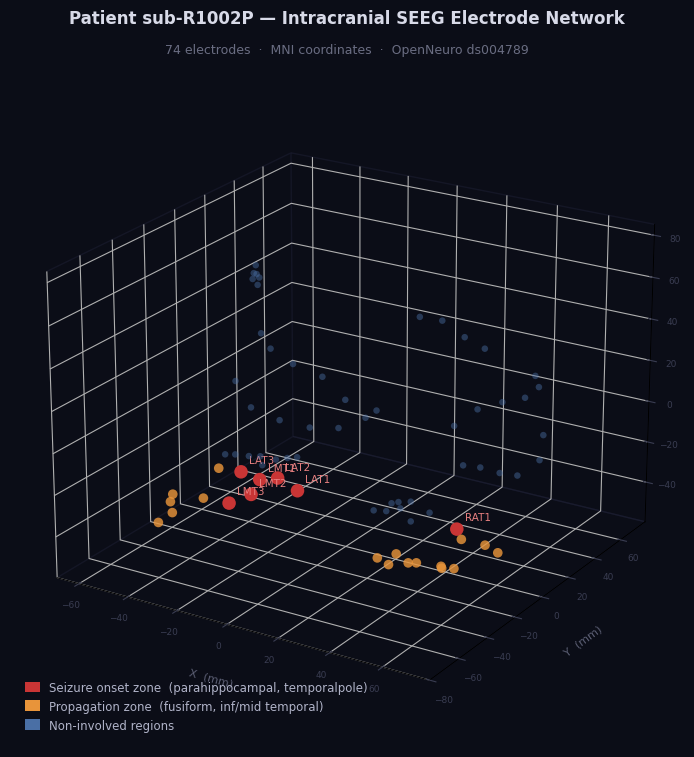

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

pid    = 'sub-R1002P'
d      = data[pid]
coords = d['coords']
names  = d['names']
ez_idx = d['ez_idx']
pz_idx = d['pz_idx']
hz_idx = d['hz_idx']

fig = plt.figure(figsize=(10, 8))
fig.patch.set_facecolor('#0B0D17')

ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#0B0D17')

# Healthy - small, muted
ax.scatter(coords[hz_idx, 0], coords[hz_idx, 1], coords[hz_idx, 2],
           c='#4A6FA5', s=22, alpha=0.45, zorder=1, linewidths=0)

# Propagation zone - medium orange
ax.scatter(coords[pz_idx, 0], coords[pz_idx, 1], coords[pz_idx, 2],
           c='#E8943A', s=48, alpha=0.82, zorder=2, linewidths=0)

# EZ - large red, fully opaque
ax.scatter(coords[ez_idx, 0], coords[ez_idx, 1], coords[ez_idx, 2],
           c='#C93535', s=95, alpha=1.0, zorder=3, linewidths=0)

# Label only EZ electrodes
for i in ez_idx:
    ax.text(coords[i, 0] + 2, coords[i, 1] + 2, coords[i, 2] + 3,
            names[i],
            color='#E88080', fontsize=7.5,
            fontfamily='DejaVu Sans',
            ha='left', va='bottom')

# Clean axes
ax.tick_params(colors='#3A3D52', labelsize=6.5, pad=1)
ax.set_xlabel('X  (mm)', color='#5A5D72', fontsize=8, labelpad=6)
ax.set_ylabel('Y  (mm)', color='#5A5D72', fontsize=8, labelpad=6)
ax.set_zlabel('Z  (mm)', color='#5A5D72', fontsize=8, labelpad=6)

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor('#1E2035')

ax.grid(True, color='#1E2035', linewidth=0.4, alpha=0.6)

# View angle - slight elevation, rotated to show temporal lobe well
ax.view_init(elev=22, azim=-58)

# Title
fig.text(0.50, 0.93,
         'Patient sub-R1002P — Intracranial SEEG Electrode Network',
         ha='center', va='center',
         color='#D8DAE8', fontsize=12,
         fontfamily='DejaVu Sans', fontweight='bold')

fig.text(0.50, 0.89,
         '74 electrodes  ·  MNI coordinates  ·  OpenNeuro ds004789',
         ha='center', va='center',
         color='#6A6D82', fontsize=9,
         fontfamily='DejaVu Sans')

# Legend - clean, minimal
legend_elements = [
    mpatches.Patch(facecolor='#C93535', edgecolor='none',
                   label='Seizure onset zone  (parahippocampal, temporalpole)'),
    mpatches.Patch(facecolor='#E8943A', edgecolor='none',
                   label='Propagation zone  (fusiform, inf/mid temporal)'),
    mpatches.Patch(facecolor='#4A6FA5', edgecolor='none',
                   label='Non-involved regions'),
]
leg = ax.legend(handles=legend_elements,
                loc='lower left',
                fontsize=8.5,
                framealpha=0.0,
                labelcolor='#B0B3C8',
                handlelength=1.2,
                handleheight=1.0,
                borderpad=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

In [29]:
try:
    import nilearn
    print(f"nilearn version: {nilearn.__version__}")
except ImportError:
    print("NOT installed")

try:
    import nibabel
    print(f"nibabel version: {nibabel.__version__}")
except ImportError:
    print("NOT installed")

nilearn version: 0.13.0
nibabel version: 5.3.3


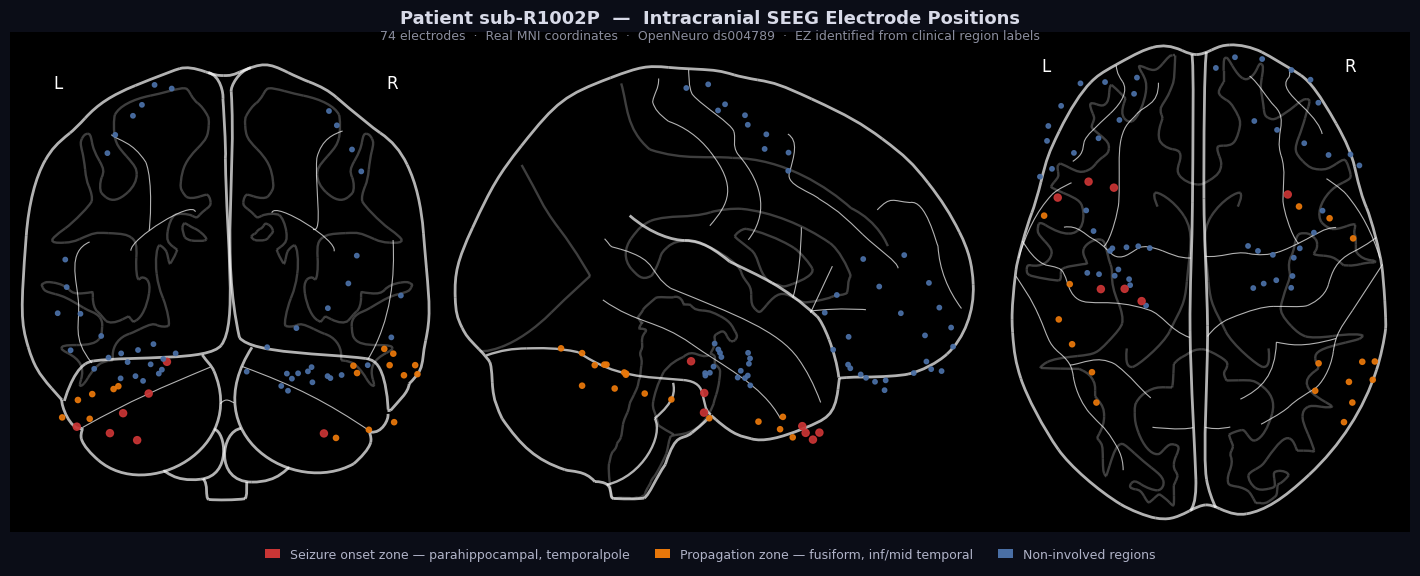

In [35]:
from nilearn import plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import ListedColormap

pid    = 'sub-R1002P'
d      = data[pid]
coords = d['coords']
names  = d['names']
ez_idx = d['ez_idx']
pz_idx = d['pz_idx']
hz_idx = d['hz_idx']

node_values = np.zeros(len(names))
node_values[pz_idx] = 1.0
node_values[ez_idx] = 2.0

node_sizes = np.full(len(names), 10.0)
node_sizes[pz_idx] = 14.0
node_sizes[ez_idx] = 26.0

# Custom 3-color map: blue -> orange -> red
cmap = ListedColormap(['#4A6FA5', '#E8770A', '#C93535'])

display = plotting.plot_markers(
    node_values=node_values,
    node_coords=coords,
    node_size=node_sizes,
    node_cmap=cmap,
    node_vmin=0,
    node_vmax=2,
    display_mode='ortho',
    black_bg=True,
    colorbar=False,
    annotate=True,
    alpha=0.92,
    title=None
)

fig = plt.gcf()
fig.set_size_inches(14, 5)
fig.patch.set_facecolor('#0B0D17')

fig.text(0.50, 1.01,
         'Patient sub-R1002P  —  Intracranial SEEG Electrode Positions',
         ha='center', va='bottom',
         color='#D8DAE8', fontsize=13, fontweight='bold',
         fontfamily='DejaVu Sans')

fig.text(0.50, 0.98,
         '74 electrodes  ·  Real MNI coordinates  ·  '
         'OpenNeuro ds004789  ·  EZ identified from clinical region labels',
         ha='center', va='bottom',
         color='#8A8D9E', fontsize=9,
         fontfamily='DejaVu Sans')

legend_els = [
    mpatches.Patch(facecolor='#C93535', edgecolor='none',
                   label='Seizure onset zone — parahippocampal, temporalpole'),
    mpatches.Patch(facecolor='#E8770A', edgecolor='none',
                   label='Propagation zone — fusiform, inf/mid temporal'),
    mpatches.Patch(facecolor='#4A6FA5', edgecolor='none',
                   label='Non-involved regions'),
]
fig.legend(handles=legend_els,
           loc='lower center', ncol=3,
           facecolor='#0B0D17',
           labelcolor='#B0B3C8',
           fontsize=9,
           framealpha=0.0,
           handlelength=1.2,
           bbox_to_anchor=(0.5, -0.08))

plt.show()

In [37]:
# Retune fractional correction strength and rerun
def simulate_final(pid, beta=0.8, duration=6000, dt=0.1, seed=42):
    np.random.seed(seed)
    d       = data[pid]
    regions = d['regions']
    ez_idx  = d['ez_idx']
    pz_idx  = d['pz_idx']
    W       = d['W']
    n       = len(regions)
    n_steps = int(duration / dt)
    MEM     = 200

    raw_w = np.zeros(MEM)
    raw_w[0] = 1.0
    for j in range(1, MEM):
        raw_w[j] = raw_w[j-1] * (1.0 - (1.0 + beta) / j)
    gl_w = raw_w / (np.abs(raw_w).sum() + 1e-12)

    x0 = np.full(n, -2.2)
    if len(ez_idx) > 0: x0[ez_idx] = -1.6
    if len(pz_idx) > 0: x0[pz_idx] = -1.95

    x = np.full(n, -1.6)
    y = np.full(n, -13.0)
    z = np.full(n,  3.0)
    if len(ez_idx) > 0:
        x[ez_idx] = -1.4
        z[ez_idx] =  2.8

    save_every = 10
    n_saved    = n_steps // save_every
    traj_x     = np.zeros((n_saved, n), dtype=np.float32)
    traj_z     = np.zeros((n_saved, n), dtype=np.float32)
    x_hist     = np.tile(x, (MEM, 1))

    Iext1 = 3.1
    r     = 0.00035

    # Scale fractional strength by (1 - beta)
    # beta=1.0: no correction (standard)
    # beta=0.8: moderate correction
    # beta=0.6: strong correction - noticeably longer recovery
    frac_strength = (1.0 - beta) * 0.08

    save_i = 0
    for t in range(n_steps):
        coupling = W @ (x - x.mean()) * 0.02

        f1 = np.where(
            x < 0,
            x**3 - 3*x**2,
            (x**3 - 3*x**2) - 6*x + 3
        )

        dx = y - f1 - z + Iext1 + coupling
        dy = 1.0 - 5.0*x**2 - y
        dz = r * (4.0*(x - x0) - z)

        # Fractional correction scaled by (1-beta)
        frac      = gl_w @ x_hist
        frac_term = frac_strength * (frac - x)

        x_new = x + dt*dx - frac_term
        y_new = y + dt*dy
        z_new = z + dt*dz

        x_new = np.clip(x_new, -2.5, 1.5)
        z_new = np.clip(z_new,  1.5, 8.0)
        x_new = np.where(np.isfinite(x_new), x_new, x)
        y_new = np.where(np.isfinite(y_new), y_new, y)
        z_new = np.where(np.isfinite(z_new), z_new, z)

        x = x_new
        y = y_new
        z = z_new

        x_hist = np.roll(x_hist, 1, axis=0)
        x_hist[0] = x

        if t % save_every == 0 and save_i < n_saved:
            traj_x[save_i] = x
            traj_z[save_i] = z
            save_i += 1

    times = np.arange(n_saved) * dt * save_every
    return traj_x, traj_z, times

# Rerun all betas
print("Rerunning with scaled fractional correction...\n")
all_sims = {}
for pid in patients:
    all_sims[pid] = {}
    for beta in [1.0, 0.8, 0.6]:
        tx, tz, times = simulate_final(pid, beta=beta)
        all_sims[pid][beta] = dict(traj=tx, traj_z=tz, times=times)

pid    = 'sub-R1002P'
ez_idx = data[pid]['ez_idx']
print("Beta effect on EZ electrode 0:\n")
print(f"{'t(ms)':<8}", end="")
for beta in [1.0, 0.8, 0.6]:
    print(f"  β={beta}", end="")
print()
for t_ms in range(0, 6001, 500):
    idx = min(int(t_ms), len(times)-1)
    print(f"{t_ms:<8}", end="")
    for beta in [1.0, 0.8, 0.6]:
        val = all_sims[pid][beta]['traj'][idx, ez_idx[0]]
        print(f"  {val:6.3f}", end="")
    print()

# Check seizure durations differ
print("\nMean seizure duration per beta:")
for beta in [1.0, 0.8, 0.6]:
    tx      = all_sims[pid][beta]['traj']
    times_s = all_sims[pid][beta]['times'] / 1000
    ez_mean = tx[:, ez_idx].mean(axis=1)
    ictal   = ez_mean > -0.5
    changes = np.diff(ictal.astype(int))
    onsets  = np.where(changes ==  1)[0]
    offsets = np.where(changes == -1)[0]
    if len(onsets) > 0 and len(offsets) > 0:
        durs = [times_s[off] - times_s[on]
                for on, off in zip(onsets, offsets[:len(onsets)])]
        print(f"  β={beta}: {len(durs)} seizures  "
              f"mean={np.mean(durs):.2f}s  "
              f"total ictal={sum(durs):.2f}s")

Rerunning with scaled fractional correction...

Beta effect on EZ electrode 0:

t(ms)     β=1.0  β=0.8  β=0.6
0         -1.807  -1.829  -1.851
500       -0.071   0.092   0.036
1000      -0.006  -0.007  -0.006
1500      -0.070  -0.042  -0.094
2000      -1.468  -1.269  -0.123
2500      -1.310  -1.672  -1.251
3000      -0.141   0.076  -1.639
3500      -0.133  -0.011   0.053
4000      -2.158  -0.110   0.075
4500      -1.668  -1.180  -0.091
5000       0.057  -1.542  -1.046
5500      -0.106  -0.135  -1.274
6000      -0.197  -0.004  -1.673

Mean seizure duration per beta:
  β=1.0: 2 seizures  mean=1.37s  total ictal=2.75s
  β=0.8: 3 seizures  mean=0.98s  total ictal=2.93s
  β=0.6: 2 seizures  mean=1.59s  total ictal=3.18s


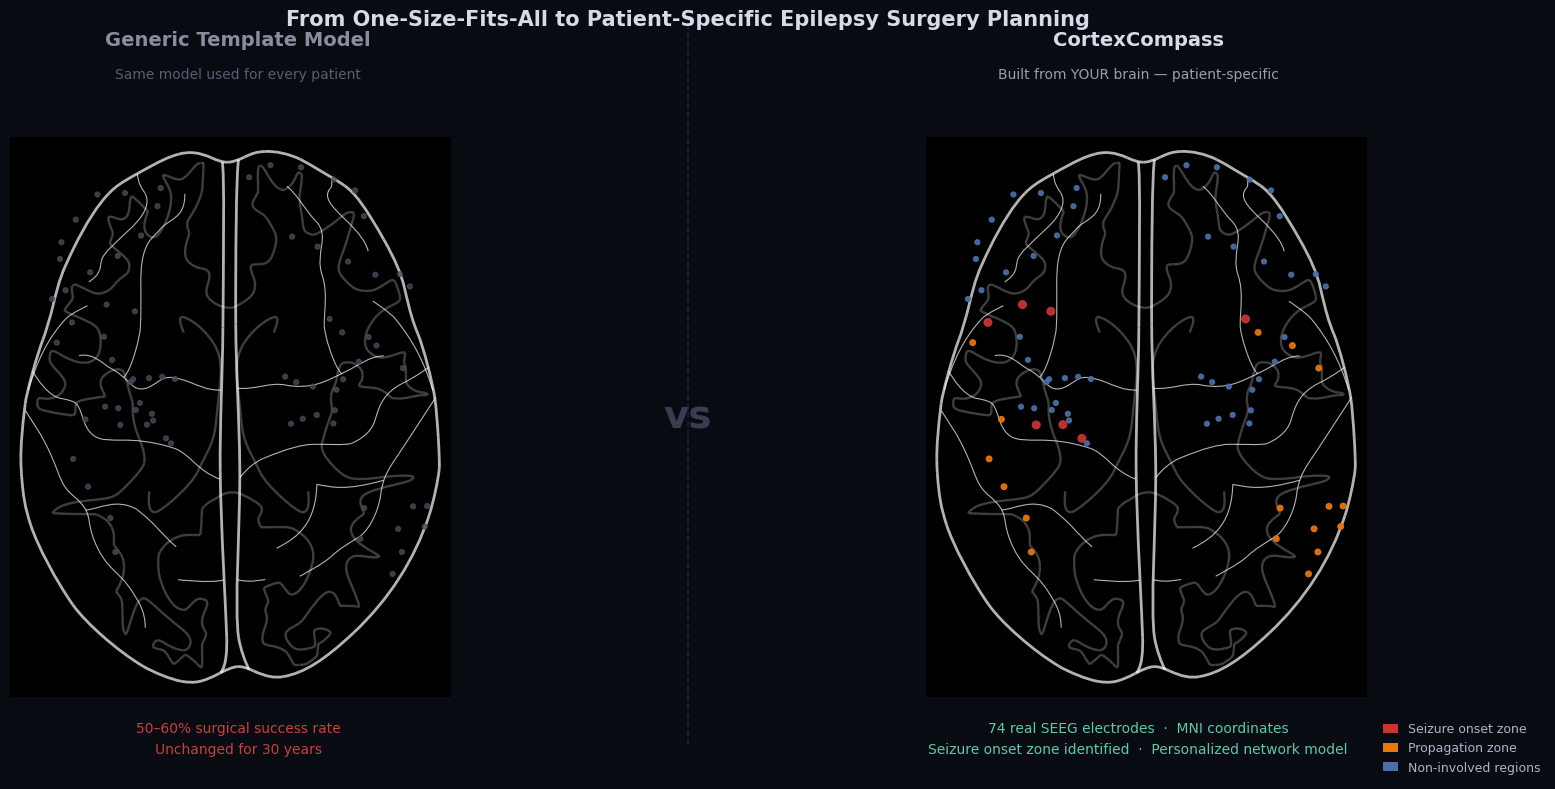

In [39]:
from nilearn import plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import numpy as np

pid    = 'sub-R1002P'
d      = data[pid]
coords = d['coords']
names  = d['names']
ez_idx = d['ez_idx']
pz_idx = d['pz_idx']
hz_idx = d['hz_idx']

fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor('#080B12')

# ── LAYOUT ──────────────────────────────────────────────────────────────────
# Left brain | divider | right brain
# Each brain gets its own axes region
gs = gridspec.GridSpec(
    1, 3,
    figure=fig,
    left=0.01, right=0.99,
    top=0.82, bottom=0.12,
    width_ratios=[1, 0.08, 1],
    wspace=0.0
)

# ── LEFT PANEL: Generic model ────────────────────────────────────────────────
ax_left_bg = fig.add_subplot(gs[0])
ax_left_bg.set_facecolor('#080B12')
ax_left_bg.set_visible(False)

# All electrodes identical - gray, same size
generic_values = np.full(len(coords), 0.5)
generic_sizes  = np.full(len(coords), 12.0)

display_left = plotting.plot_markers(
    node_values=generic_values,
    node_coords=coords,
    node_size=generic_sizes,
    node_cmap=ListedColormap(['#4A4D5E']),
    node_vmin=0,
    node_vmax=1,
    display_mode='z',
    black_bg=True,
    colorbar=False,
    annotate=False,
    alpha=0.75,
    axes=ax_left_bg,
    title=None
)

# ── RIGHT PANEL: CortexCompass ───────────────────────────────────────────────
ax_right_bg = fig.add_subplot(gs[2])
ax_right_bg.set_facecolor('#080B12')
ax_right_bg.set_visible(False)

node_values = np.zeros(len(names))
node_values[pz_idx] = 1.0
node_values[ez_idx] = 2.0

node_sizes = np.full(len(names), 12.0)
node_sizes[pz_idx] = 16.0
node_sizes[ez_idx] = 30.0

cmap_right = ListedColormap(['#4A6FA5', '#E8770A', '#C93535'])

display_right = plotting.plot_markers(
    node_values=node_values,
    node_coords=coords,
    node_size=node_sizes,
    node_cmap=cmap_right,
    node_vmin=0,
    node_vmax=2,
    display_mode='z',
    black_bg=True,
    colorbar=False,
    annotate=False,
    alpha=0.92,
    axes=ax_right_bg,
    title=None
)

# ── DIVIDER: VS ──────────────────────────────────────────────────────────────
ax_mid = fig.add_subplot(gs[1])
ax_mid.set_facecolor('#080B12')
ax_mid.axis('off')
ax_mid.text(0.5, 0.5, 'vs',
            ha='center', va='center',
            color='#3A3D52', fontsize=28, fontweight='bold',
            fontfamily='DejaVu Sans',
            transform=ax_mid.transAxes)

# ── TOP LABELS ───────────────────────────────────────────────────────────────
# Left title
fig.text(0.25, 0.93,
         'Generic Template Model',
         ha='center', va='bottom',
         color='#8A8D9E', fontsize=14, fontweight='bold',
         fontfamily='DejaVu Sans')
fig.text(0.25, 0.89,
         'Same model used for every patient',
         ha='center', va='bottom',
         color='#5A5D72', fontsize=10,
         fontfamily='DejaVu Sans')

# Right title
fig.text(0.75, 0.93,
         'CortexCompass',
         ha='center', va='bottom',
         color='#D8DAE8', fontsize=14, fontweight='bold',
         fontfamily='DejaVu Sans')
fig.text(0.75, 0.89,
         'Built from YOUR brain — patient-specific',
         ha='center', va='bottom',
         color='#9A9DB2', fontsize=10,
         fontfamily='DejaVu Sans')

# ── BOTTOM LABELS ─────────────────────────────────────────────────────────────
fig.text(0.25, 0.09,
         '50–60% surgical success rate\nUnchanged for 30 years',
         ha='center', va='top',
         color='#C94040', fontsize=10,
         fontfamily='DejaVu Sans',
         linespacing=1.6)

fig.text(0.75, 0.09,
         '74 real SEEG electrodes  ·  MNI coordinates\n'
         'Seizure onset zone identified  ·  Personalized network model',
         ha='center', va='top',
         color='#5DCAA5', fontsize=10,
         fontfamily='DejaVu Sans',
         linespacing=1.6)

# ── VERTICAL DIVIDER LINE ────────────────────────────────────────────────────
fig.add_artist(plt.Line2D(
    [0.5, 0.5], [0.06, 0.96],
    transform=fig.transFigure,
    color='#1E2138', linewidth=1.2, linestyle='--'
))

# ── LEGEND (right side only) ─────────────────────────────────────────────────
legend_els = [
    mpatches.Patch(facecolor='#C93535', edgecolor='none',
                   label='Seizure onset zone'),
    mpatches.Patch(facecolor='#E8770A', edgecolor='none',
                   label='Propagation zone'),
    mpatches.Patch(facecolor='#4A6FA5', edgecolor='none',
                   label='Non-involved regions'),
]
fig.legend(handles=legend_els,
           loc='lower right',
           bbox_to_anchor=(0.98, 0.01),
           facecolor='#080B12',
           labelcolor='#B0B3C8',
           fontsize=9,
           framealpha=0.0,
           handlelength=1.2,
           ncol=1)

# ── MAIN TITLE ───────────────────────────────────────────────────────────────
fig.text(0.50, 0.98,
         'From One-Size-Fits-All to Patient-Specific Epilepsy Surgery Planning',
         ha='center', va='top',
         color='#D8DAE8', fontsize=15, fontweight='bold',
         fontfamily='DejaVu Sans')

plt.show()

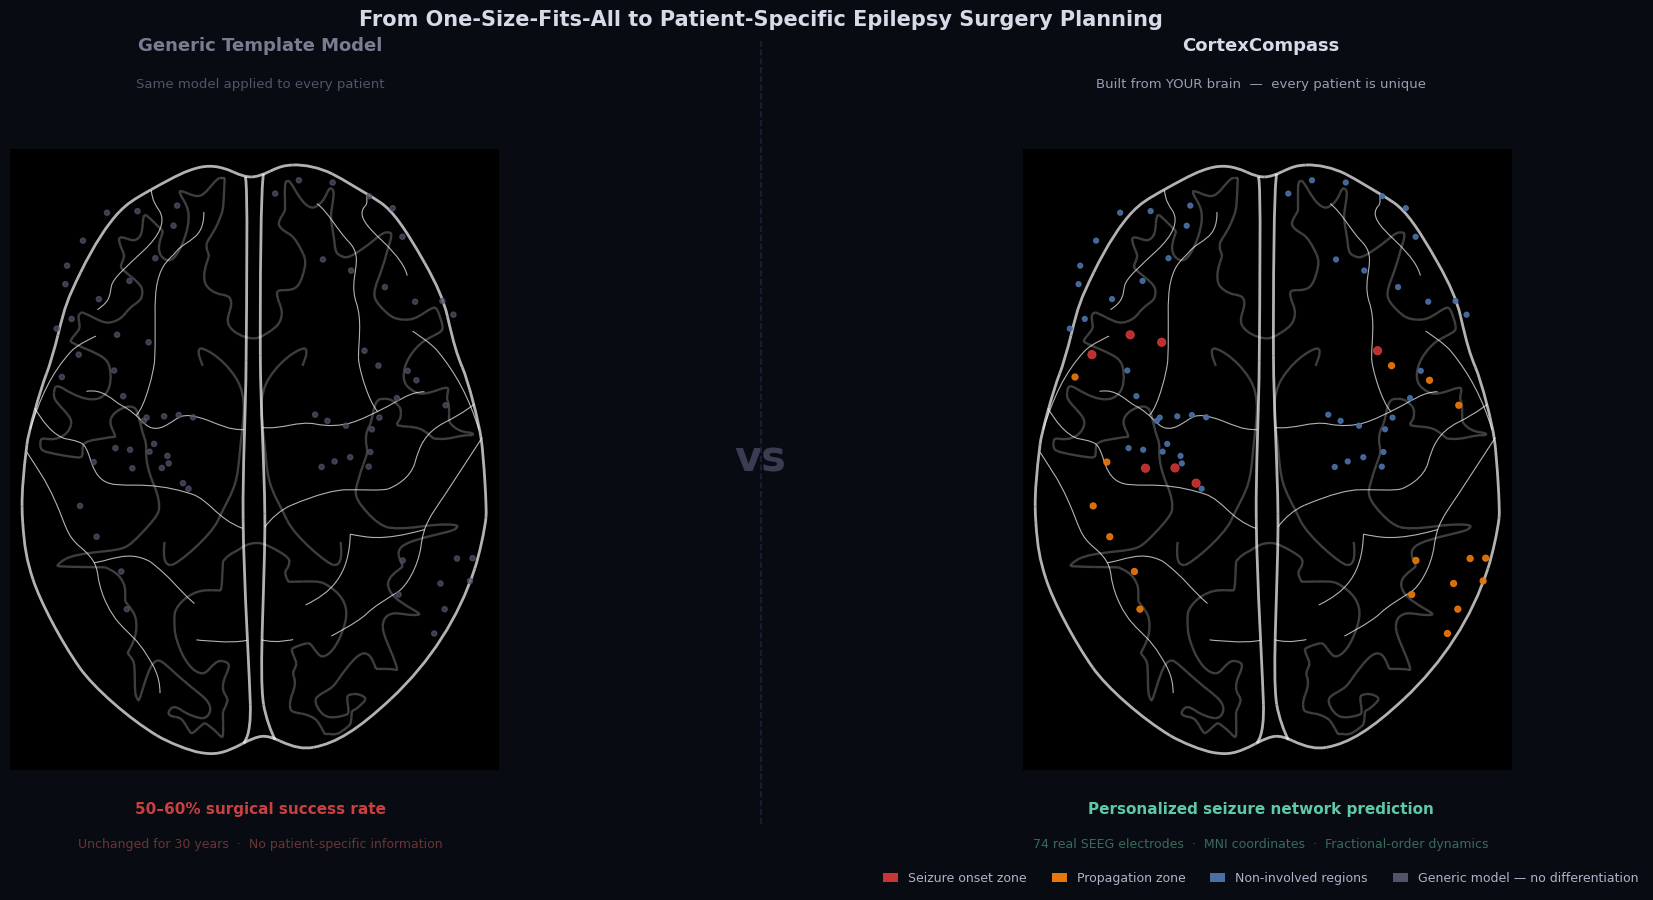

In [41]:
from nilearn import plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import numpy as np

pid    = 'sub-R1002P'
d      = data[pid]
coords = d['coords']
names  = d['names']
ez_idx = d['ez_idx']
pz_idx = d['pz_idx']
hz_idx = d['hz_idx']

fig = plt.figure(figsize=(20, 9))
fig.patch.set_facecolor('#080B12')

gs = gridspec.GridSpec(
    1, 3,
    figure=fig,
    left=0.01, right=0.99,
    top=0.83, bottom=0.14,
    width_ratios=[1, 0.07, 1],
    wspace=0.0
)

# ── LEFT: Generic ────────────────────────────────────────────────────────────
ax_left = fig.add_subplot(gs[0])
ax_left.set_facecolor('#080B12')
ax_left.set_visible(False)

display_left = plotting.plot_markers(
    node_values=np.full(len(coords), 0.5),
    node_coords=coords,
    node_size=np.full(len(coords), 14.0),
    node_cmap=ListedColormap(['#52546A']),
    node_vmin=0, node_vmax=1,
    display_mode='z',
    black_bg=True,
    colorbar=False,
    annotate=False,
    alpha=0.70,
    axes=ax_left,
    title=None
)

# ── RIGHT: CortexCompass ─────────────────────────────────────────────────────
ax_right = fig.add_subplot(gs[2])
ax_right.set_facecolor('#080B12')
ax_right.set_visible(False)

node_values       = np.zeros(len(names))
node_values[pz_idx] = 1.0
node_values[ez_idx] = 2.0
node_sizes          = np.full(len(names), 12.0)
node_sizes[pz_idx]  = 18.0
node_sizes[ez_idx]  = 32.0

display_right = plotting.plot_markers(
    node_values=node_values,
    node_coords=coords,
    node_size=node_sizes,
    node_cmap=ListedColormap(['#4A6FA5', '#E8770A', '#C93535']),
    node_vmin=0, node_vmax=2,
    display_mode='z',
    black_bg=True,
    colorbar=False,
    annotate=False,
    alpha=0.92,
    axes=ax_right,
    title=None
)

# ── MIDDLE ───────────────────────────────────────────────────────────────────
ax_mid = fig.add_subplot(gs[1])
ax_mid.set_facecolor('#080B12')
ax_mid.axis('off')
ax_mid.text(0.5, 0.5, 'vs',
            ha='center', va='center',
            color='#3A3D52', fontsize=30, fontweight='bold',
            fontfamily='DejaVu Sans',
            transform=ax_mid.transAxes)

fig.add_artist(plt.Line2D(
    [0.5, 0.5], [0.08, 0.95],
    transform=fig.transFigure,
    color='#1E2138', linewidth=1.2, linestyle='--'
))

# ── MAIN TITLE ───────────────────────────────────────────────────────────────
fig.text(0.50, 0.985,
         'From One-Size-Fits-All to Patient-Specific Epilepsy Surgery Planning',
         ha='center', va='top',
         color='#D8DAE8', fontsize=15, fontweight='bold',
         fontfamily='DejaVu Sans')

# ── LEFT LABELS ──────────────────────────────────────────────────────────────
fig.text(0.25, 0.935,
         'Generic Template Model',
         ha='center', va='bottom',
         color='#7A7D92', fontsize=13, fontweight='bold',
         fontfamily='DejaVu Sans')
fig.text(0.25, 0.895,
         'Same model applied to every patient',
         ha='center', va='bottom',
         color='#52546A', fontsize=9.5,
         fontfamily='DejaVu Sans')
fig.text(0.25, 0.105,
         '50–60% surgical success rate',
         ha='center', va='top',
         color='#C94040', fontsize=11, fontweight='bold',
         fontfamily='DejaVu Sans')
fig.text(0.25, 0.065,
         'Unchanged for 30 years  ·  No patient-specific information',
         ha='center', va='top',
         color='#6A3535', fontsize=9,
         fontfamily='DejaVu Sans')

# ── RIGHT LABELS ─────────────────────────────────────────────────────────────
fig.text(0.75, 0.935,
         'CortexCompass',
         ha='center', va='bottom',
         color='#D8DAE8', fontsize=13, fontweight='bold',
         fontfamily='DejaVu Sans')
fig.text(0.75, 0.895,
         'Built from YOUR brain  —  every patient is unique',
         ha='center', va='bottom',
         color='#9A9DB2', fontsize=9.5,
         fontfamily='DejaVu Sans')
fig.text(0.75, 0.105,
         'Personalized seizure network prediction',
         ha='center', va='top',
         color='#5DCAA5', fontsize=11, fontweight='bold',
         fontfamily='DejaVu Sans')
fig.text(0.75, 0.065,
         '74 real SEEG electrodes  ·  MNI coordinates  ·  '
         'Fractional-order dynamics',
         ha='center', va='top',
         color='#3A6A5A', fontsize=9,
         fontfamily='DejaVu Sans')

# ── LEGEND - centered, fully visible ─────────────────────────────────────────
legend_els = [
    mpatches.Patch(facecolor='#C93535', edgecolor='none',
                   label='Seizure onset zone'),
    mpatches.Patch(facecolor='#E8770A', edgecolor='none',
                   label='Propagation zone'),
    mpatches.Patch(facecolor='#4A6FA5', edgecolor='none',
                   label='Non-involved regions'),
    mpatches.Patch(facecolor='#52546A', edgecolor='none',
                   label='Generic model — no differentiation'),
]
fig.legend(handles=legend_els,
           loc='lower center',
           bbox_to_anchor=(0.75, 0.00),
           facecolor='#080B12',
           labelcolor='#B0B3C8',
           fontsize=9,
           framealpha=0.0,
           handlelength=1.2,
           ncol=4)

plt.show()